In [15]:
import os, time
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

%matplotlib inline
for d in ["plots", "models"]: os.makedirs(d, exist_ok=True)
print("Setup complete.")


Setup complete.


In [16]:
audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]
tracks_path = "../datasets/tracks.csv"


In [17]:
tracks = pd.read_csv(tracks_path)
tracks = tracks.dropna(subset=["name"])
tracks = tracks.sort_values("popularity", ascending=False)
tracks = tracks.drop_duplicates(subset=["name", "id_artists"], keep="first")
tracks = tracks[
    (tracks["duration_ms"] > 0) & (tracks["tempo"] > 0) &
    (tracks["time_signature"] > 0) & (tracks["popularity"] > 0)
]
tracks["release_date"] = pd.to_datetime(tracks["release_date"], format="mixed")
tracks["year"] = tracks["release_date"].dt.year
tracks = tracks[tracks["year"] >= 1950]

dataframe1 = tracks[
    (tracks["release_date"] >= "2010-01-01") &
    (tracks["release_date"] <= "2020-12-31")
].copy()
print(f"2010-2020 rows: {len(dataframe1):,}")


2010-2020 rows: 102,507


In [18]:
# getting our one hot encoder
dataframe1["key"] = dataframe1["key"].astype(int)
key_dummies  = pd.get_dummies(dataframe1["key"],  prefix="key",  dtype=int)
mode_dummies = pd.get_dummies(dataframe1["mode"], prefix="mode", dtype=int)

#keeping numeric colmns
numeric_columns = audio_features + ["explicit", "time_signature", "duration_ms"]
features = pd.concat([dataframe1[numeric_columns], key_dummies, mode_dummies], axis=1)
feature_names = list(features.columns)

HIT_THRESHOLD = 50 # this is just the baseline
binary_target = (dataframe1["popularity"] > HIT_THRESHOLD).astype(int).values

#binary classification
n_hit, n_not = binary_target.sum(), (binary_target == 0).sum()
print(f"Hit:  {n_hit:,}  ({n_hit/len(binary_target):.1%})")
print(f"Not Hit:    {n_not:,}  ({n_not/len(binary_target):.1%})")


Hit:  35,474  (34.6%)
Not Hit:    67,033  (65.4%)


In [19]:
# our validation set will be 2020 data
mask_2020 = (dataframe1["year"] == 2020)

# holdout is the validation we are using
X_holdout = features[mask_2020].values
y_holdout= binary_target[mask_2020]

#X train test, y train test
X_traintest= features[~mask_2020].values
y_tt = binary_target[~mask_2020]

# scale the data
scaler= StandardScaler()
X_tt_scaled  = scaler.fit_transform(X_traintest)
X_val_scaled = scaler.transform(X_holdout)

# 80-20 train test for 2010-2019 data
X_train, X_test, y_train, y_test = train_test_split(
    X_tt_scaled, y_tt, test_size=0.2, random_state=42, stratify=y_tt,
)
print(f"Train: {len(X_train):,} |  Test: {len(X_test):,} |  Holdout: {len(X_val_scaled):,}")


Train: 72,328 |  Test: 18,083 |  Holdout: 12,096


In [20]:
mask_2020

92811      True
92810      True
92813      True
92814      True
92819      True
          ...  
481451    False
416009    False
218212    False
535739    False
218255    False
Name: year, Length: 102507, dtype: bool

## Exploratory Plots

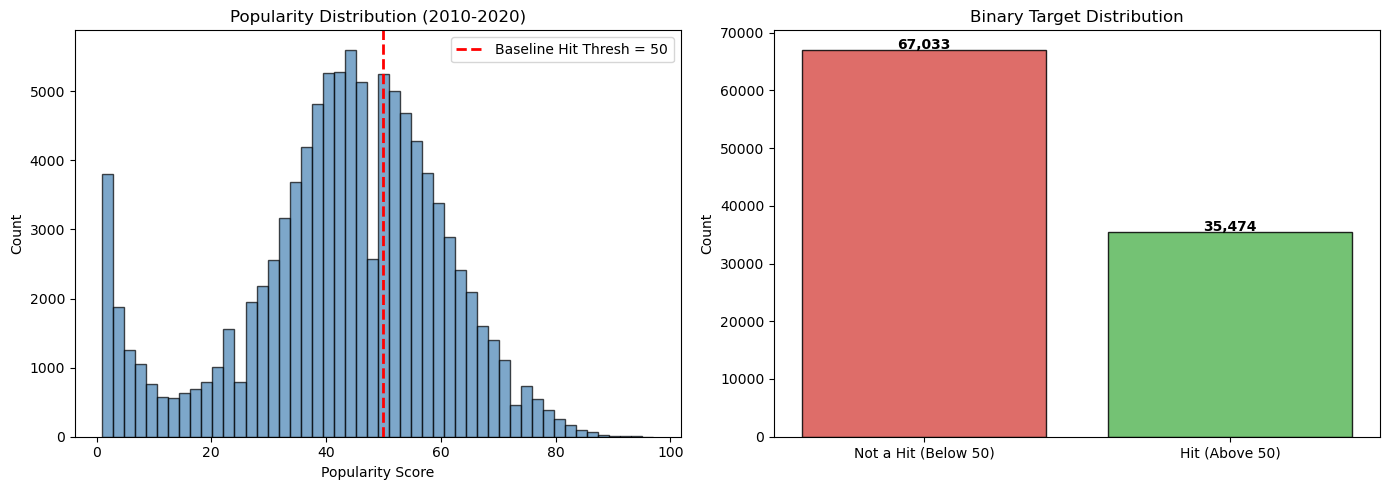

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dataframe1["popularity"], bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(HIT_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Baseline Hit Thresh = {HIT_THRESHOLD}")
axes[0].set_xlabel("Popularity Score"); axes[0].set_ylabel("Count")
axes[0].set_title("Popularity Distribution (2010-2020)"); axes[0].legend()
axes[1].bar(["Not a Hit (Below 50)", "Hit (Above 50)"], [n_not, n_hit],
            color=["#d9534f","#5cb85c"], edgecolor="black", alpha=0.85)
axes[1].set_ylabel("Count"); axes[1].set_title("Binary Target Distribution")
for i, v in enumerate([n_not, n_hit]):
    axes[1].text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout(); plt.savefig("plots/binary_target_distribution.png", dpi=150); plt.show()


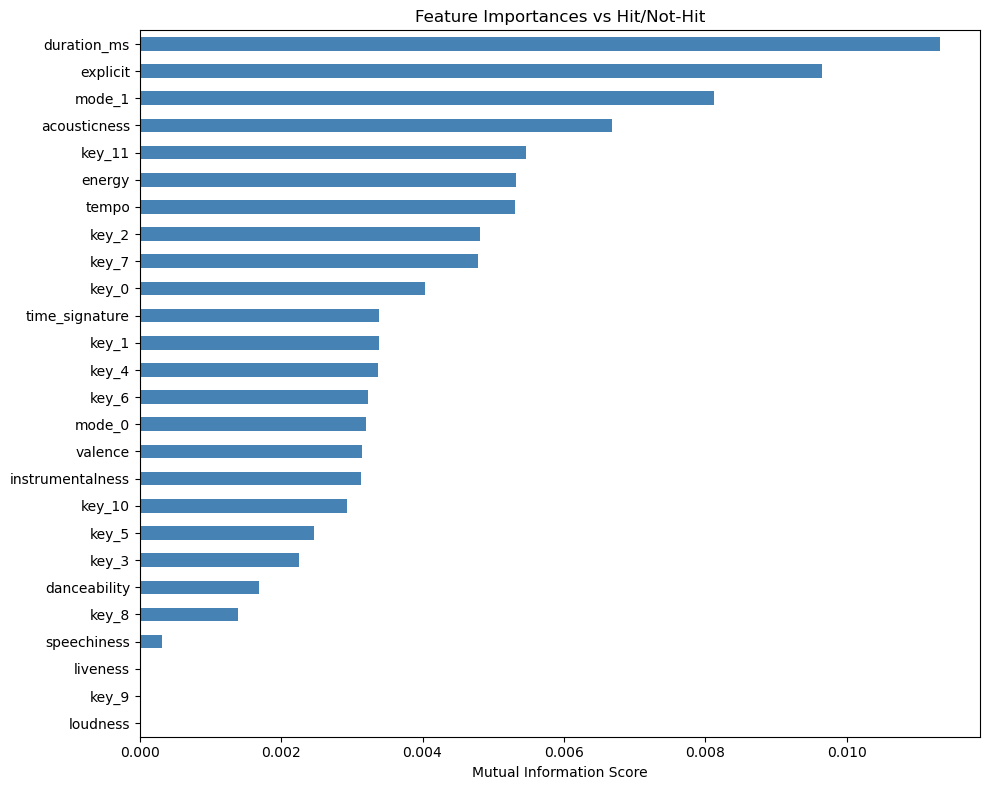

In [22]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
mi_series.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Mutual Information Score")
ax.set_title("Feature Importances vs Hit/Not-Hit")
plt.tight_layout(); plt.savefig("plots/feature_importance_binary.png", dpi=150); plt.show()


In [23]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np

# 1. Define the parameter grids using ONLY the fields from your example
# testing balanced vs None for all models that support class_weight
param_grids = {
    "Logistic Regression": {
        "max_iter": [500, 1000, 2000],
        "class_weight": ["balanced", None]
    },
    "Naive Bayes": {
        # Standard tuning field for NB since your example was empty
        "var_smoothing": np.logspace(0, -9, num=10)
    },
    "KNN (k=15)": {
        "n_neighbors": [5, 10, 15, 20, 25, 50]
    },
    "Random Forest": {
        "n_estimators": [200, 400, 600],
        "max_depth": [10, 25, 50, None],
        "class_weight": ["balanced", None]
    },
    "Extra Trees": {
        "n_estimators": [100, 300, 500],
        "max_depth": [10, 20, 30, None],
        "class_weight": ["balanced", None]
    },
    "HistGradientBoosting": {
        "max_iter": [100, 400, 600],
        "max_depth": [5, 10, 20],
        "learning_rate": [0.01, 0.05, 0.1],
        "min_samples_leaf": [10, 20, 50],
        "class_weight": ["balanced", None]
    }
}

# 2. Re-initialize candidate models with their fixed defaults from your code
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

candidate_models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN (k=15)": KNeighborsClassifier(n_jobs=-1),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
}

# 3. Grid Search Execution (Optimized for roc_auc)
best_results_auc = {}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in candidate_models.items():
    print(f"--- Optimizing AUC for: {name} ---")
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=cv_strategy,
        scoring='roc_auc', # Metric changed to ROC AUC
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_results_auc[name] = {
        "params": grid_search.best_params_,
        "auc_score": grid_search.best_score_,
        "estimator": grid_search.best_estimator_
    }
    
    print(f"Best Params: {grid_search.best_params_}")
    print(f"Best Mean CV AUC: {grid_search.best_score_:.4f}\n")

# 4. Final Comparison Table
import pandas as pd
auc_summary = pd.DataFrame([
    {
        "Model": k, 
        "Best AUC": v["auc_score"], 
        "Optimal Class Weight": v["params"].get("class_weight", "N/A"),
        "Best Parameters": v["params"]
    } 
    for k, v in best_results_auc.items()
]).sort_values(by="Best AUC", ascending=False)

print(auc_summary)

--- Optimizing AUC for: Logistic Regression ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'class_weight': None, 'max_iter': 500}
Best Mean CV AUC: 0.6276

--- Optimizing AUC for: Naive Bayes ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'var_smoothing': np.float64(1.0)}
Best Mean CV AUC: 0.6053

--- Optimizing AUC for: KNN (k=15) ---
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'n_neighbors': 50}
Best Mean CV AUC: 0.6196

--- Optimizing AUC for: Random Forest ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/opt/homebrew/Caskroom/miniconda/base/envs/ecs171/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'class_weight': 'balanced', 'max_depth': 25, 'n_estimators': 600}
Best Mean CV AUC: 0.6804

--- Optimizing AUC for: Extra Trees ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/opt/homebrew/Caskroom/miniconda/base/envs/ecs171/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ecs171/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ecs171/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warning

Best Params: {'class_weight': None, 'max_depth': 20, 'n_estimators': 500}
Best Mean CV AUC: 0.6596

--- Optimizing AUC for: HistGradientBoosting ---
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Params: {'class_weight': None, 'learning_rate': 0.05, 'max_depth': 10, 'max_iter': 400, 'min_samples_leaf': 50}
Best Mean CV AUC: 0.6796

                  Model  Best AUC Optimal Class Weight  \
3         Random Forest  0.680360             balanced   
5  HistGradientBoosting  0.679590                  NaN   
4           Extra Trees  0.659619                  NaN   
0   Logistic Regression  0.627626                  NaN   
2            KNN (k=15)  0.619635                  N/A   
1           Naive Bayes  0.605282                  N/A   

                                     Best Parameters  
3  {'class_weight': 'balanced', 'max_depth': 25, ...  
5  {'class_weight': None, 'learning_rate': 0.05, ...  
4  {'class_weight': None, 'max_depth': 20, 'n_est...  
0            {'cla

In [24]:
# 1. Create a new dictionary to store only the best estimators
# This replaces your initial 'candidate_models' with the optimized ones
best_candidate_models = {name: results["estimator"] for name, results in best_results_auc.items()}

print("--- Best Parameters Extracted ---\n")

for name, results in best_results_auc.items():
    print(f"Model: {name}")
    print(f"Best AUC Score: {results['auc_score']:.4f}")
    print("Parameters:")
    for param, value in results["params"].items():
        print(f"  - {param}: {value}")
    print("-" * 30)

# 2. (Optional) If you want to see them as a clean DataFrame for documentation
import pandas as pd
best_params_df = pd.DataFrame([
    {"Model": name, **results["params"], "Mean_AUC": results["auc_score"]}
    for name, results in best_results_auc.items()
])

# Display the summary table
best_params_df

--- Best Parameters Extracted ---

Model: Logistic Regression
Best AUC Score: 0.6276
Parameters:
  - class_weight: None
  - max_iter: 500
------------------------------
Model: Naive Bayes
Best AUC Score: 0.6053
Parameters:
  - var_smoothing: 1.0
------------------------------
Model: KNN (k=15)
Best AUC Score: 0.6196
Parameters:
  - n_neighbors: 50
------------------------------
Model: Random Forest
Best AUC Score: 0.6804
Parameters:
  - class_weight: balanced
  - max_depth: 25
  - n_estimators: 600
------------------------------
Model: Extra Trees
Best AUC Score: 0.6596
Parameters:
  - class_weight: None
  - max_depth: 20
  - n_estimators: 500
------------------------------
Model: HistGradientBoosting
Best AUC Score: 0.6796
Parameters:
  - class_weight: None
  - learning_rate: 0.05
  - max_depth: 10
  - max_iter: 400
  - min_samples_leaf: 50
------------------------------


,Model,class_weight,max_iter,Mean_AUC,var_smoothing,n_neighbors,max_depth,n_estimators,learning_rate,min_samples_leaf
0,Logistic Regression,NaN,500.0,0.627626,NaN,NaN,NaN,NaN,NaN,NaN
1,Naive Bayes,NaN,NaN,0.605282,1.0,NaN,NaN,NaN,NaN,NaN
2,KNN (k=15),NaN,NaN,0.619635,NaN,50.0,NaN,NaN,NaN,NaN
3,Random Forest,balanced,NaN,0.680360,NaN,NaN,25.0,600.0,NaN,NaN
4,Extra Trees,NaN,NaN,0.659619,NaN,NaN,20.0,500.0,NaN,NaN
5,HistGradientBoosting,NaN,400.0,0.679590,NaN,NaN,10.0,NaN,0.05,50.0
